This article that we're gonna explore is about HOODIE, which is a distributed hybrid task offloading scheme. It jointly optimize the task latency and drop rate, under dynamic CEC(cloud-Edge Computing) traffic.<br>

Hybrid task offloading is where some agent or something, should decide a task to run locally, offloaded vertically to the cloud, or horizontally to interconnected edge servers.<br>

HOODIE employs a model-free DRL framework, where distributed DRL agents at each edge server autonomously determine offloading decisions without global task distribution awareness.<br>

This method incorporate techniques such as LSTM, Dueling deep Q-networks, and double-DQN.<br>


Tasks that gets offloaded can suffer from delays or be dropped entirely when deadlines are missed, particularly under fluctuating network conditions and resource limitations.<br>

The primary goal of task offloading is to optimize system performance by minimizing target indicators, such as latency, energy consumption and drop ratio, to prevent bottlenecks and ensure smooth and efficient flow of CEC operations.

There are three primary methods for agents to operate in a computing environment, particularly for task offloading: heuristic, centralized, and distributed(or decentralized) ML.


**Heuristic Methods**:

Heuristic methods are widely used for task offloading, often focusing on finding near-optimal solutions by simplifying complex environments and relaxing the constraints of non-convex optimization problems. These methods rely on predefined rules or approximations that may not generalize well across different scenarios.<br>
**Cons**: They can provide significant performance improvements and insights. <br>
**Pros**: They often lack adaptability to dynamic network conditions and can be computationally complex, making their use in large-scale, online operations quiostionable.


**Centralized ML**:

Centralized ML methods involve a single, central model that makes optimal decisions based on historical data or real-time global inputs from all individual nodes. These methods are often based on DRL framework. <br>
**Pros**: They can effectively handle complex offloading scenarios and aim to optimize for global performance. <br>
**Cons**: But they face significant scalability limitations because the central model must manage a large number of devices and tasks, potentially leading to bottlenecks. They also require centralized data collection, which can raise security concerns and increase bandwidth overhead. Centralized models also lack the flexibility to adapt to hybrid offloading scenarios involving both vertical and horizontal task flows.

**Distributed ML**:

Distributed ML methods deploy models across multiple nodes, allowing each node to make local decisions autonomously. These local agents can also collaborate with other nodes to optimize global performance. They offer a response to the scalability and security issues centralized approaches. <br>
**Pros**: They are adaptive to local conditions and can contribute to global optimization without requiring a central authority.<br>
**Cons**: Existing distributed models often focus on specific offloading types (e.g., IoT-to-Cloud or edge-to-cloud) and may not fully support hybrid task flows, leading to suboptimal resource utilization in complex environments. Coordination overhead between agents can also be significant, especially in large-scale networks, which may introduce additional delays and network traffic. 


HOODIE agents exploit the **Double and Dueiling DRL** techniques for **learning stability**. To proactively adapt to **time-varying** workloads, the proposed algorithm considers as DRL inputs both local task features and forecasts about upcoming load in CEC. 

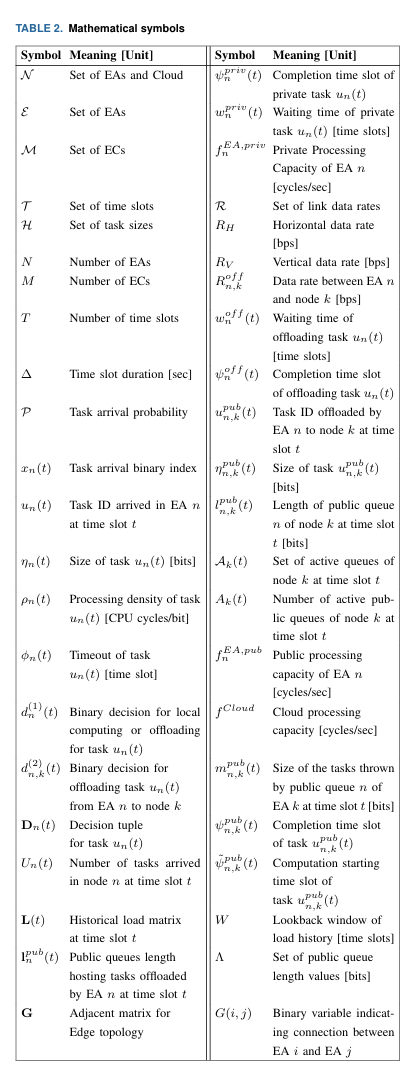

+ $\mathcal{N}$: Is the set of EAs and cloud: $\mathcal{N} = \{1, 2, ..., N + 1\}$<br>

+ $\epsilon$: Is only the set of EAs without cloud: $\epsilon = \mathcal{N} - \{N+1\} = \{1, 2, ..., N\}$

+ Each $n \in \epsilon$ is responsible for computing all tasks (or applications) generated by the respective IoT area

+ Tasks are non-divisible (no partial offloading)

+ We have $M$ Edge controller(EC), that there are two scenarios: Each EC is in charge of monitoring a signle EA ($M = N$), or each EC is reponsible for a cluster of EAs ($M < N$)

+ EC is able to transfer data from an EA to controller, whereas intercontroller communication is also allowed to enable data provisioning across different clusters of EAs.

+ Episode: Finite set of time slots, $\mathcal{T} = \{1, 2, ..., T\}$, with each time-slot $t \in \mathcal{T}$ having a duration $\Delta$(in seconds)

Internal structure of each EA:

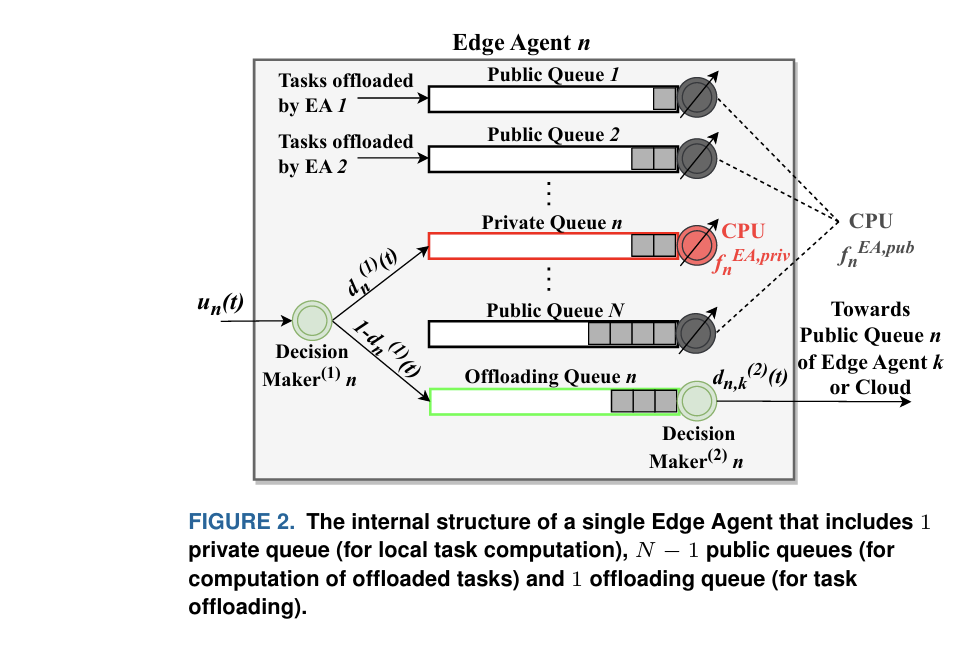

+ $u_n(t)$: Task ID arrived in EA $n$ at time slot $t$
+ $d_n^{(1)}(t)$: Binary decision for local computing or offloading for task $u_n(t)$
+ $d_{n, k}^{(2)}(t)$: Binary decision for offloading task $u_n(t)$ from EA $n$ to node $k$
+ $f_n^{\text{EA, priv}}$: Private processing capacity of EA $n$ in [cycles/sec]
+ $\mathcal{P}$: Task arrival probability


At the **beginning of each time slot**, EA $n$ has a new task arrival with a certain probability $\mathcal{P}$, additionaly eah EA has dual behavior, meaning that it can either act as local computing node for the tasks associated with the corresponding IoT area or host computational tasks that are offloaded by another EA. To this end, each EA $n \in \epsilon$ is equipped with *N* FIFO computation queues to execute tasks and 1 offloaing queue to stack the tasks to be offloaded. For EA $n$, the computation queue $n$ is called *private queue* because it is used for computing the local taks, whereas the rest of $N-1$ computation queues are called *public queues* because they are used to host external tasks. The public queue $n' \in \epsilon - \{n\}$ of each EA $n \in \epsilon$ stacks the tasks offloaded by EA $n'$. For instance, if EA 5 offloads a task to EA 3, then the offloaded task is placed in public queue 5 of EA 3. <br>
The **cloud** includes only *N* public queues, with its public queue $n \in \epsilon$ hosting the tasks forwarded by EA $n$. We assume also that when the computation (or offloading) of a task is completed in a time slot, then the next task in the queue will be computed (or offloaded) at the **beginning of the next time slot**


+ $x_n(t)$: Task arrival binary index 

At a given time slot $t$, we use the binary variable $x_n(t)$ to denote if a new local task is arrived in EA $n$ as:

$$x_n(t) = \begin{cases} 1, & \text{if a new task arrived in EA n at time t} \\ 0, & \text{otherwise} \end{cases}$$

Under the above definition, the task ID can be written as $u_n(t) = x_n(t) . u_n(t)$, i.e. the task ID is set to zero if no task arrived.

+ $\eta_{n}(t)$: size of task $u_n(t)$ in [bits]


The values of task size are drawn from the discrete set $\mathcal{H} = \{\eta_1, \eta_2, ..., \eta_{|\mathcal{H}|}\}$

The size of task $u_n(t)$ can be also written as $\eta_n(t) = x_n(t) . \eta_n(t)$ meaning that the size of task is zero when there is no local task arrived in EA $n$ at time slot $t$. According to this notations, we have $\eta_n(t) \in \mathcal{H} \cup \{0\}, \forall n \in \epsilon$


+ $\rho_n(t)$: processing density of task $u_n(t)$ in [CPU cycles/bit] -> defines the number of CPU cycles required to process a unit of data
+ $\phi_n(t)$: timeout index of task $u_n(t)$ in (time slots) -> implies that the task $u_n(t)$ should have been computed until the time slot $t + \phi_n - 1$ otherwise it is dropped.


The output of Decision-Maker 1 in the architecture:

$$d_n^{(1)}(t) = \begin{cases} 1, & u_n(t)\text{ is placed in private queue} \\ 0, & u_n(t) \text{ is placed in offloading queue} \end{cases}$$

#### Offloading Decision Model

The output of Decision-Maker 2 in the architecture:

$$d_{n,k}^{(2)}(t) = \begin{cases} 1, & \text{if } d_n^{(1)}(t) = 0 \text{ and } u_n(t) \text{ is offloaded from EA n to node k} \\ 0, & \text{ if } d_n^{(1)}(t) = 1 \text{ (local computation)} \end{cases}$$


> Each EA has a dual role, acting as both local computing node and a host for tasks offloading from other EAs. The key difference between private and public queues lies in the **source** of the tasks they handle.

**Private Queue**:<br>
+ **purpose**: The private queue is used exclusively for tasks generated by the local IoT area that the EA is responsible for. Tasks in this queue are processed using the EA's dedicated private CPU, denoted as $f_n^{\text{EA, priv}}$

**Public Queue**:<br>

+ **purpose**: The public queues are designed to host and process tasks that have been offloaded from other EAs. An EA has $N-1$ public queues to accommodate tasks from other EAs, and a cloud entity has N public queues from all EAs. Taks in these queues are processsed by a separate public CPU, $f_n^{\text{EA, pub}}$. This processing capacity is **shared equally** among all active queues at any given time.

The number of bits occupied n the private queue (and offloading queue) of EA *n* at time slot *t* equal to:

+ $d_n^{(1)}. \eta_n(t)$ and $(1 - d_n^{(1)}).\eta_n(t)$

A task can be offloaded to at most one destination node, as reflected by the formula below:
$$\sum_{k \in \mathcal{N} - \{n\}} d_{n, k}^{(2)}(t) \leq 1, \forall n \in \epsilon$$

The number of tasks arrived at the computation queues (private plus public queues) of computation node $n \in \mathcal{N}$ at time slot $t$ is given by:
$$U_n(t) = \begin{cases} d_n^{(1)} (t) + \sum_{i \in \epsilon - \{n\}} d_{i, n}^{(2)}(t), & \text{if } n \in \epsilon \\ \sum_{i \in \epsilon} d_{i, n}^{(2)}(t), & \text{if } n = N + 1 \end{cases}$$



+ $U_n(t)$ is differently calculated for EAs (they have both private and public queues) and the Cloud (it has only public queues.). The first branch reflects the number of tasks arrived in EA *n* at time slot *t* as the sum of the tasks that are going to be locally computed (first term) plus the tasks that are offloaded by other EAs (second term). The second branch represents the number of tasks arrived in the cloud at time slot *t* as the sum of the offloaded tasks that have the cloud as computing destinatin.

We define:

$$D_n(t) = (d_{n, k}^{(2)}(t), k \in \mathcal{N} - \{n\})$$

Which is a decision tuple, which reflects the computing destination of task $u_n(t)$. For 

#### Offloading Queue Model

similar to private model, the offloading queue of each EA is a FIFO queue which is responsible for stacking the local tasks to be offloaded. Once a local task $u_n(t)$ of EA $n \in \epsilon$ is selected for offloading, the offloading queue of the source EA is connected to the target **public queue** of the destination EA or the Cloud through a wired link. Since it is not always possible to assume all-to-all connectivity across EA in practice, we can let the symmetrical matrix $G$ denote the adjacent graph of the Edge layer topology, with each element $G(i, j) = G(j, i) = 1$ when EA $i$ can establish direct bidirectional connection with EA $j$, whereas $G(i, j) = 0$ otherwise.


+ $\R_H$: link data rate for the horizontal EA-to-EA communication is assumed constant for each pair of EAs.
+ $\R_V$: link data rate of the vertical EA-to-Cloud communication is assumed constant for each EA-Cloud pair.
+ $\mathcal{R} = \{\R_H, \R_V\}$ denote the set of available data rates, Where $R_H$ and $R_V$ are measured in bits/sec with $R_H > R_V$. 


If EA $n \in \epsilon$ offloads $u_n(t)$ to computation node $k \in \mathcal{N} - \{n\}$ (another EA or cloud), the data rate $R_{n,k}^{\text{off}}$ of the communication link is calculated as follows:

$$R_{n, k}^{\text{off}} = \begin{cases} R_H, & \text{if } k \in \epsilon - n \\ R_V, & \text{if } k = N + 1 \end{cases}, \forall n \in  \epsilon$$

We also have the two variables below like in private queue:

+ $w_n^{\text{off}}(t)$: waiting time in the offloading queue.
+ $\psi_n^{\text{off}}(t)$: task completion time slot.


The completion time for a task: Is when the task has been offloaded or has been dropped.<br>

> For example $\psi_6^{\text{off}}(5) = 16$ means that the task arrived at $t = 5$ in EA 6 and placed in the offloading queue will be completed at $t = 16$

The number of time slots required by task $u_n(t)$ to wait in the offloading queue(until completion) is:
$$w_n^{\text{off}}(t) = \max\{0, \max_{t' < t}\{\psi_n^{\text{off}}(t')\} - t + 1\}, \forall n \in \epsilon$$


To compute the completion time slot of a task $u_n(t)$ that is placed in the offloading queue of EA n:

$$\psi_n^{\text{off}}(t) = \min \{t + w_n^{\text{off}}(t) + \lceil \sum_{k \in \mathcal{N} - \{n\}} \frac{d_{n, k}^{(2)}(t) . \eta_n(t)}{R_{n, k}^{\text{off}}. \Delta} \rceil - 1, t + \phi_n(t) - 1\}, \forall n \in \epsilon$$

#### Public Queue Model

Each EA $n \in \epsilon$ has $N - 1$ public to host the processing of external tasks offloaded by other EAs. The Cloud entity maintains $N$ public queues, being capable of hosting the processing of the tasks offloaded by all the EAs.<br>
Each public queue is matched with the offloading EA.


Upon placement of the offloaded task $u_n(t)$ in the public queue $n$ of EA $k$ at time slot $t$, a **new task ID** $u_{n, k}^{\text{pub}}(t) \in Z_{+}$ is assigned to the task, ensuring that the task with source node $n$, destination node $k$ and queue placement time slot $t$ has a unique identifier.

$$u_{n, k}^{\text{pub}}(t) = \begin{cases} u_n(t'), & \text{if EA n offloaded to node k} \\ 0, & \text{otherwise} \end{cases}$$

Where $u_n(t')$ stands for task ID arrived at EA $n \in \epsilon$ at time slot $t' \in \{0, 1, ..., t - 1\}$. This means that the ID assigned to the task at the public queue of node $k$ is identical with the original task ID assigned when the task was initially arrived in the source node $n$.

We also define $\eta_{n, k}^{\text{pub}}(t) \in \mathcal{H} \cup \{0\}$ as the size (in bits) of the task arrived in the public queue.

+ $l_{n, k}^{\text{pub}}(t)$: Represents the length (in bits) of the public queue $n$ of node $k$ at the **end** of the time slot $t$.

+ **Active queue**: A public queue *n* of node *k* is called active queue at time slot *t* if and only if either a new task is inserted to the public queue at time slot *t* (i.e. $\eta_{n, k}^{\text{pub}} (t) > 0$) or there are queued tasks at the end of the previous time slot (i.e. $l_{n, k}^{\text{pub}}(t - 1) > 0$)

The set of active public queues of node $k \in \mathcal{N}$ at each time slot $t \in \mathcal{T}$ is defined as:

$$\mathcal{A}_k(t) = \begin{cases} n|\eta_{n, k}^{\text{pub}}(t) > 0 or l_{n, k}^{\text{pub}} > 0, ... n \in \epsilon - \{k\}, & \text{if } k \in \epsilon \text{for EAs} \\ n|\eta_{n, k}^{\text{pub}}(t) > 0 or l_{n, k}^{\text{pub}} > 0, ... n \in \epsilon, & \text{if } k = N + 1 \text{for clouds} \end{cases}$$

Each EA is equipped with **another CPU** $f_n^{\text{EA, pub}}$ in (Hz) for processing the tasks stacked up in the **public queues**.<br>
We let $f_1^{\text{EA, pub}} = f_2^{\text{EA, pub}} = ... = f_N^{\text{EA, pub}}$ Where as the cloud has a CPU of $f^{\text{cloud}}$ Hz, with $f^{\text{cloud}} > f_n^{\text{EA, pub}}$

+ $m_{n, k}^{\text{pub}}(t)$: denote the size (in bits) of the tasks thrown by the public queue $n \in \epsilon$ of node $k \in \mathcal{N} - \{n\}$ at the end of time slot $t$. 


The public queue length:

$$l_{n,k}^{\text{pub}}(t) = \max \{0, l_{n, k}^{\text{pub}}(t - 1) + \eta_{n, k}^{\text{pub}}(t) - m_{n, k}^{\text{pub}}(t) - \frac{\Delta. f_k^{\text{EA, pub}}}{\rho_n(t). A_k(t)}  \}$$


+ $\psi_{n,k}^{\text{pub}}(t) \in \mathcal{T}$: completion (task completion or timeout) time slot of the task $u_{n, k}^{\text{pub}}(t)$

Given the **load uncerntainaty** over time and that the $\psi_{n,k}^{\text{pub}}(t)$ cannot be known by neither the EA *n* nor the node *k* **before the task has been actually addressed(processed or thrown)**, we can **indirectly** define the value of $\psi_{n,k}^{\text{pub}}(t)$ basd on the time slot **starting** the computation (of task $u_{n, k}^{\text{pub}}$) $\tilde{\psi}_{n,k}^{\text{pub}}(t)$. And we're gonna have:

$$\tilde{\psi}_{n,k}^{\text{pub}}(t) = \max \{t, \max_{t' < t} \psi_{n,k}^{\text{pub}}(t') + 1\}$$

+ The equation above says that the task either starts being processed immediately after its arrival to node *k* (i.e. at time slot t) or waits the most-demanding of the previously stored tasks to be finished and starts being processed at the next time slot.

#### Historical Load Levels

ECs(Edge controler) keep track of the historical timeseries of each EA and the Cloud. Load of a node *k* at time slot *t* is expressed as the **number of active queues** $A_k(t)$.<br>

ECs maintain a matrix of the load levels per node, denoted as $L(t)$, with the dimension of $W \times (N + 1)$:
+ $W$: Lookback window, which is a parameter that defines the number of preivous time slots an agent considers to track the historical load levels of computing node in the network.
+ $N + 1$: Number of the computing nodes(i.e., all the EAs plus Cloud)

So in each column $j \in \mathcal{N}$ the load of node $j$ from the time slot $t - W$ to time slot $t - 1$. Each element $(i, j)$ of matrix $L(t)$ reflects the number of active queue of node $j$ at time slot $t - W + i - 1$, as expressed in the following:

$$
L_{i,j}(t) = A_j(t - W + i - 1), \quad
\forall i \in \{1, 2, 3, \dots, W\}, \ \forall j \in \mathcal{N}
$$

+ $\max\{L_{i,j}(t) = N - 1\}$ for $i \in \{1, 2, 3, ..., W\}$ and $j \in \epsilon$ Whereas $\max\{L_{i,j}(t) = N\}$ for $i \in \{1, 2, 3, ..., W\}$ and $j = N + 1$ (max number of active queuein the cloud):

$$L(t) = \begin{pmatrix} A_1(t - W) & ... & A_{N + 1}(t - W) \\ A_1(t - W + 1) & ... & A_{N + 1}(t - W + 1) \\ . & . & . \\ . &  . & . \\ . &   . &  . \\ A_1(t - 1) & ... & A_{N + 1}(t - 1) \end{pmatrix}$$